# Descrição do caso 🧑🏼‍🔬


Projeto Complementar: Análise de Fenilcetonúria

Descrição: Paciente lactente bebê, sexo masculino, 6 meses, apresentada na consulta de pediatria
geneticista devido a triagem neonatal alterada evidenciando níveis elevados de fenilalanina e
atraso incipiente no desenvolvimento neuropsicomotor.
Procedimento: Painel genético específico para análise de variantes no gene PAH, realizado a partir
de amostra de sangue.

Objetivo: Identificar variantes genéticas responsáveis pela fenilcetonúria (PKU), fornecendo base
para diagnóstico precoce e orientações terapêuticas individualizadas para prevenção de
complicações neurológicas.
  



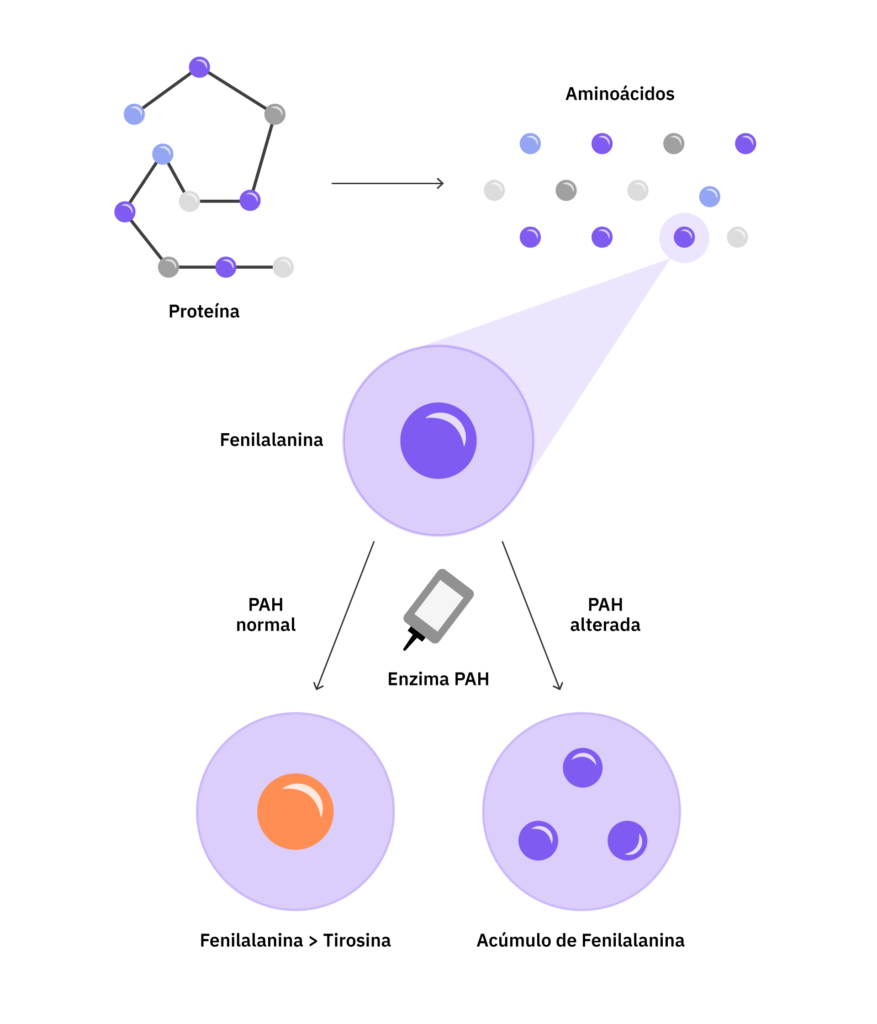

# Planejamento do Pipeline


In [ ]:
#Instalação dos arquivos direto do drive (Arquivos pesados)
!pip install gdown
!gdown --id 1RxiW3cFlgEatVq0T52A54EzzOTNw54jO
!gdown --id 1L5K1zsQF7KfecKr86pR3KWQoePFbw07M
!gdown --id 1Pf3GJQUYEYHK_D4LqMGNdchutzxYjG0M

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1RxiW3cFlgEatVq0T52A54EzzOTNw54jO
From (redirected): https://drive.google.com/uc?id=1RxiW3cFlgEatVq0T52A54EzzOTNw54jO&confirm=t&uuid=5d540017-96e3-4122-bc46-370155adc1ee
To: /content/Chr12-reference.fasta.gz
100% 39.5M/39.5M [00:01<00:00, 38.8MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1L5K1zsQF7KfecKr86pR3KWQoePFbw07M
From (redirected): https://drive.google.com/uc?id=1L5K1zsQF7KfecKr86pR3KWQoePFbw07M&confirm=t&uuid=fa8bd09f-8833-4683-9ada-6d8e01256068
To: /content/

# 0. Configuração de Ambiente **padrão**

In [ ]:
%%bash
# Instalar miniconda e mamba (feito nas aulas passadas; ambos são ferramentas de gerenciamento
wget --quiet https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh
bash Miniforge3-Linux-x86_64.sh -b -p /usr/local -u
mamba init
mamba config set auto_activate_base true
mamba shell init --shell bash --root-prefix=~/.local/share/mamba
rm Miniforge3-Linux-x86_64.sh

PREFIX=/usr/local
Unpacking payload ...
Extracting _libgcc_mutex-0.1-conda_forge.tar.bz2
Extracting ca-certificates-2025.7.14-hbd8a1cb_0.conda
Extracting ld_impl_linux-64-2.44-h1423503_1.conda
Extracting libgomp-15.1.0-h767d61c_3.conda
Extracting pybind11-abi-4-hd8ed1ab_3.tar.bz2
Extracting python_abi-3.12-8_cp312.conda
Extracting tzdata-2025b-h78e105d_0.conda
Extracting _openmp_mutex-4.5-2_gnu.tar.bz2
Extracting libgcc-15.1.0-h767d61c_3.conda
Extracting c-ares-1.34.5-hb9d3cd8_0.conda
Extracting libexpat-2.7.1-hecca717_0.conda
Extracting libffi-3.4.6-h2dba641_1.conda
Extracting libgcc-ng-15.1.0-h69a702a_3.conda
Extracting libiconv-1.18-h4ce23a2_1.conda
Extracting liblzma-5.8.1-hb9d3cd8_2.conda
Extracting libnsl-2.0.1-hb9d3cd8_1.conda
Extracting libstdcxx-15.1.0-h8f9b012_3.conda
Extracting libzlib-1.3.1-hb9d3cd8_2.conda
Extracting ncurses-6.5-h2d0b736_3.conda
Extracting openssl-3.5.1-h7b32b05_0.conda
Extracting reproc-14.2.5.post0-hb9d3cd8_0.conda
Extracting bzip2-1.0.8-h4bc722e_7.conda

warning  libmamba [python-3.12.11-h9e4cc4f_0_cpython] The following files were already present in the environment:
    - bin/python
warning  libmamba [charset-normalizer-3.4.2-pyhd8ed1ab_0] The following files were already present in the environment:
    - bin/normalizer
warning  libmamba [distro-1.9.0-pyhd8ed1ab_1] The following files were already present in the environment:
    - bin/distro
warning  libmamba [jsonpointer-3.0.0-py312h7900ff3_1] The following files were already present in the environment:
    - bin/jsonpointer
warning  libmamba [wheel-0.45.1-pyhd8ed1ab_1] The following files were already present in the environment:
    - bin/wheel
warning  libmamba [jsonpatch-1.33-pyhd8ed1ab_1] The following files were already present in the environment:
    - bin/jsondiff
    - bin/jsonpatch
warning  libmamba [pip-25.1.1-pyh8b19718_0] The following files were already present in the environment:
    - bin/pip
    - bin/pip3
warning  libmamba [tqdm-4.67.1-pyhd8ed1ab_1] The following fil

In [ ]:
%%bash
# Instalação dos softwares a serem utilizados
mamba install -c bioconda -c conda-forge fastqc bwa gatk4 cutadapt samtools bedtools ensembl-vep=115 -y


Pinned packages:

  - python=3.12


Transaction

  Prefix: /usr/local

  Updating specs:

   - fastqc
   - bwa
   - gatk4
   - cutadapt
   - samtools
   - bedtools
   - ensembl-vep=115


  Package                                           Version  Build                  Channel           Size
────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Install:
────────────────────────────────────────────────────────────────────────────────────────────────────────────

  + alsa-lib                                         1.2.11  hd590300_1             conda-forge      555kB
  + argtable2                                          2.13  hd590300_1004          conda-forge        2MB
  + bedtools                                         2.31.1  hf5e1c6e_2             bioconda           2MB
  + binutils_impl_linux-64                             2.44  h4bf12b8_1             conda-forge        4MB
  + binutils_linux-64                          

warning  libmamba [mysql-libs-8.3.0-hca2cd23_4] The following files were already present in the environment:
    - lib/libmysqlclient.so
warning  libmamba [mysql-server-8.3.0-h27b9c54_4] The following files were already present in the environment:
    - bin/my_print_defaults
    - bin/perror
warning  libmamba [mysql-devel-8.3.0-hf1915f5_4] The following files were already present in the environment:
    - bin/mysql_config
    - lib/libmysqlclient.a
/tmp/mambaf7qc462ua3u: line 2: /usr/local/bin/mamba (deleted): No such file or directory
/tmp/mambaf7qc462ua3u: line 3: syntax error near unexpected token `deleted'
/tmp/mambaf7qc462ua3u: line 3: `mamba (deleted) activate "/usr/local"'
/tmp/mambafqp5eath47g: line 2: /usr/local/bin/mamba (deleted): No such file or directory
/tmp/mambafqp5eath47g: line 3: syntax error near unexpected token `deleted'
/tmp/mambafqp5eath47g: line 3: `mamba (deleted) activate "/usr/local"'


In [ ]:
%%bash
# Testando se a instalação funcionou
vep --help

#----------------------------------#
# ENSEMBL VARIANT EFFECT PREDICTOR #
#----------------------------------#

Versions:
  ensembl              : 115.266b84d
  ensembl-compara      : 115.ae48a7a
  ensembl-funcgen      : 115.57f7061
  ensembl-io           : 115.25061d3
  ensembl-variation    : 115.b7c2637
  ensembl-vep          : 115.2

Help: dev@ensembl.org , helpdesk@ensembl.org
Twitter: @ensembl

http://www.ensembl.org/info/docs/tools/vep/script/index.html

Usage:
./vep [--cache|--offline|--database] [arguments]

Basic options

--help                 Display this message and quit

-i | --input_file      Input file
-o | --output_file     Output file
--force_overwrite      Force overwriting of output file
--species [species]    Species to use [default: "human"]

--everything           Shortcut switch to turn on commonly used options. See web
                       documentation for details [default: off]
--fork [num_forks]     Use forking to improve script runtime

For full option doc

In [ ]:
%%bash
# Criar as pastas para organizar os arquivos que serão gerados
mkdir -p raw fastqc cutadapt bwa gatk vep reference

In [ ]:
%%bash
# Mover arquivos para as suas respectivas pastas e descompactar fasta.gz
mv *.fastq.gz raw/
gunzip -c Chr12-reference.fasta.gz > reference/Chr12-reference.fasta
rm -rf Chr12-reference.fasta.gz sample_data/

# 1. Controle de Qualidade

In [ ]:
%%bash
# Gerar o relatório da qualidade dos reads de sequenciamento
fastqc -o fastqc/ raw/caso2-sindrome-metabolica_R1.fastq.gz raw/caso2-sindrome-metabolica_R2.fastq.gz

application/gzip
application/gzip
Analysis complete for caso2-sindrome-metabolica_R1.fastq.gz
Analysis complete for caso2-sindrome-metabolica_R2.fastq.gz


Started analysis of caso2-sindrome-metabolica_R1.fastq.gz
Approx 5% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 10% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 15% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 20% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 25% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 30% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 35% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 40% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 45% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 50% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 55% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 60% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 65% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 70% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 75% complete for caso2-sindrome-metabolica_R1.fastq.gz
Approx 80% co

In [ ]:
%%bash
# Filtrar sequências muito pequenas e cortar as pontas
cutadapt \
  -u 5 -U 5 \
  -u -5 -U -5 \
  -m 90 \
  -o cutadapt/caso2-sindrome-metabolica_trimmed_R1.fastq.gz \
  -p cutadapt/caso2-sindrome-metabolica_trimmed_R2.fastq.gz \
  raw/caso2-sindrome-metabolica_R1.fastq.gz \
  raw/caso2-sindrome-metabolica_R2.fastq.gz

This is cutadapt 5.2 with Python 3.12.3
Command line parameters: -u 5 -U 5 -u -5 -U -5 -m 90 -o cutadapt/caso2-sindrome-metabolica_trimmed_R1.fastq.gz -p cutadapt/caso2-sindrome-metabolica_trimmed_R2.fastq.gz raw/caso2-sindrome-metabolica_R1.fastq.gz raw/caso2-sindrome-metabolica_R2.fastq.gz
Processing paired-end reads on 1 core ...

=== Summary ===

Total read pairs processed:          3,000,000

== Read fate breakdown ==
Pairs that were too short:                   2 (0.0%)
Pairs written (passing filters):     2,999,998 (100.0%)

Total basepairs processed:   900,007,113 bp
  Read 1:   450,024,803 bp
  Read 2:   449,982,310 bp
Total written (filtered):    840,006,660 bp (93.3%)
  Read 1:   420,024,574 bp
  Read 2:   419,982,086 bp


In [ ]:
#Interpretando a saída desse passo, observamos que quase todos os pares foram mantidos (99,9999%). Apenas 6,7% das bases foram eliminadas, possivelmente sendo essas as extremidades cortadas.

# 2. Mapeamento com a referência do genoma humano

In [ ]:
%%bash
# Indexar o genoma humano de referência para realizar o mapeamento e posterior remoção de contaminante (cerca de 3 min)
samtools faidx reference/Chr12-reference.fasta
bwa index reference/Chr12-reference.fasta

[bwa_index] Pack FASTA... 1.15 sec
[bwa_index] Construct BWT for the packed sequence...
[BWTIncCreate] textLength=266550618, availableWord=30755168
[BWTIncConstructFromPacked] 10 iterations done. 50732074 characters processed.
[BWTIncConstructFromPacked] 20 iterations done. 93723498 characters processed.
[BWTIncConstructFromPacked] 30 iterations done. 131930362 characters processed.
[BWTIncConstructFromPacked] 40 iterations done. 165884698 characters processed.
[BWTIncConstructFromPacked] 50 iterations done. 196059354 characters processed.
[BWTIncConstructFromPacked] 60 iterations done. 222874650 characters processed.
[BWTIncConstructFromPacked] 70 iterations done. 246704106 characters processed.
[BWTIncConstructFromPacked] 80 iterations done. 266550618 characters processed.
[bwt_gen] Finished constructing BWT in 80 iterations.
[bwa_index] 109.45 seconds elapse.
[bwa_index] Update BWT... 1.14 sec
[bwa_index] Pack forward-only FASTA... 0.73 sec
[bwa_index] Construct SA from BWT and Occ.

In [ ]:
%%bash
# Proceder com o alinhamento contra o genoma humano
bwa mem reference/Chr12-reference.fasta \
  -R '@RG\tID:sample1\tSM:sample1\tPL:ILLUMINA\tLB:lib1\tPU:unit1' \
  cutadapt/caso2-sindrome-metabolica_trimmed_R1.fastq.gz \
  cutadapt/caso2-sindrome-metabolica_trimmed_R2.fastq.gz \
  | samtools sort -o bwa/caso2-sindrome-metabolica-mapped-host.bam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 71422 sequences (10000189 bp)...
[M::process] read 71440 sequences (10000217 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (0, 34793, 0, 0)
[M::mem_pestat] skip orientation FF as there are not enough pairs
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (319, 339, 359)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (239, 439)
[M::mem_pestat] mean and std.dev: (340.01, 28.20)
[M::mem_pestat] low and high boundaries for proper pairs: (199, 479)
[M::mem_pestat] skip orientation RF as there are not enough pairs
[M::mem_pestat] skip orientation RR as there are not enough pairs
[M::mem_process_seqs] Processed 71422 reads in 23.769 CPU sec, 23.609 real sec
[M::process] read 71420 sequences (10000023 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (0, 34716, 0, 0)
[M::mem_pestat] skip orientatio

In [ ]:
%%bash
# Indexar o bam para gerar o bai e visualizar no IGV
samtools index bwa/caso2-sindrome-metabolica-mapped-host.bam

# 3. Chamada de Variantes

In [ ]:
%%bash
# Indexar a referência e BAM para chamada de variantes com GATK
samtools dict reference/Chr12-reference.fasta > reference/Chr12-reference.dict
samtools index bwa/caso2-sindrome-metabolica-mapped-host.bam

In [ ]:
%%bash
# Chamada de variantes
gatk HaplotypeCaller \
  -R reference/Chr12-reference.fasta \
  -I bwa/caso2-sindrome-metabolica-mapped-host.bam \
  -O gatk/caso2-sindrome-metabolica-host-variants.vcf

# 4. Anotação de Variantes

In [ ]:
%%bash
# script oficial baixa cache do genoma humano (grande volume de dados, demora cerca de 60 min)
vep_install -a cf -s homo_sapiens -y GRCh38 --NO_UPDATE

 - getting list of available cache files
 - downloading https://ftp.ensembl.org/pub/release-115/variation/indexed_vep_cache/homo_sapiens_vep_115_GRCh38.tar.gz
 - unpacking homo_sapiens_vep_115_GRCh38.tar.gz
 - converting cache, this may take some time but will allow VEP to look up variants and frequency data much faster
 - use CTRL-C to cancel if you do not wish to convert this cache now (you may run convert_cache.pl later)
2025-10-31 16:37:36 - Processing homo_sapiens
2025-10-31 16:37:36 - Processing version 115_GRCh38
2025-10-31 16:37:36 - No unprocessed types remaining, skipping
2025-10-31 16:37:36 - All done!
 - downloading Homo_sapiens.GRCh38.dna.toplevel.fa.gz
 - downloading Homo_sapiens.GRCh38.dna.toplevel.fa.gz.fai
 - downloading Homo_sapiens.GRCh38.dna.toplevel.fa.gz.gzi

The FASTA file should be automatically detected by the VEP when using --cache or --offline.
If it is not, use "--fasta /root/.vep/homo_sapiens/115_GRCh38/Homo_sapiens.GRCh38.dna.toplevel.fa.gz"


All done


Unable to close datastream at /usr/local/bin/vep_install line 1385.


In [ ]:
%%bash
# Index VCF files para anotação
bgzip gatk/caso2-sindrome-metabolica-host-variants.vcf
tabix -p vcf gatk/caso2-sindrome-metabolica-host-variants.vcf.gz

In [ ]:
%%bash
# Anotação de variantes a nível de proteína
vep -i gatk/caso2-sindrome-metabolica-host-variants.vcf.gz \
    --output_file vep/caso2-sindrome-metabolica-host-variants.vep.tsv \
    --tab --force_overwrite \
    --offline --cache --dir_cache ~/.vep \
    --assembly GRCh38 \
    --symbol --hgvs --canonical --af_1kg --max_af \
    --everything --pick\
    --stats_file vep/caso2-sindrome-metabolica-host-variants.vep.html


In [ ]:
%%bash
# Anotação de variantes a nível de proteína
vep -i gatk/caso2-sindrome-metabolica-host-variants.vcf.gz \
    --output_file vep/caso2-sindrome-metabolica-variants.vep.tsv \
    --tab --force_overwrite \
    --offline --cache --dir_cache ~/.vep \
    --assembly GRCh38 \
    --symbol --hgvs --canonical --af_1kg --max_af \
    --everything --pick \
    --stats_file vep/caso2-sindrome-metabolica-host-variants.vep.html


# 5. Predição de efeito

 **Arquivo html do paciente (FASTQC REPORT):**
As leituras dos dados retirados do paciente possuem boa estrutura, no entando sua qualidade é variável. Apesar dos trimmings realizados com o cutadapt, ainda seria necessário submeter a amostra à outro trimming, com a retirada de dados de bases com qualidade maior que 20. Ainda que esses resultados não sejam anormais para dados crus de sequenciamento, espera-se um melhor desempenho após aplicar essa ferramenta.

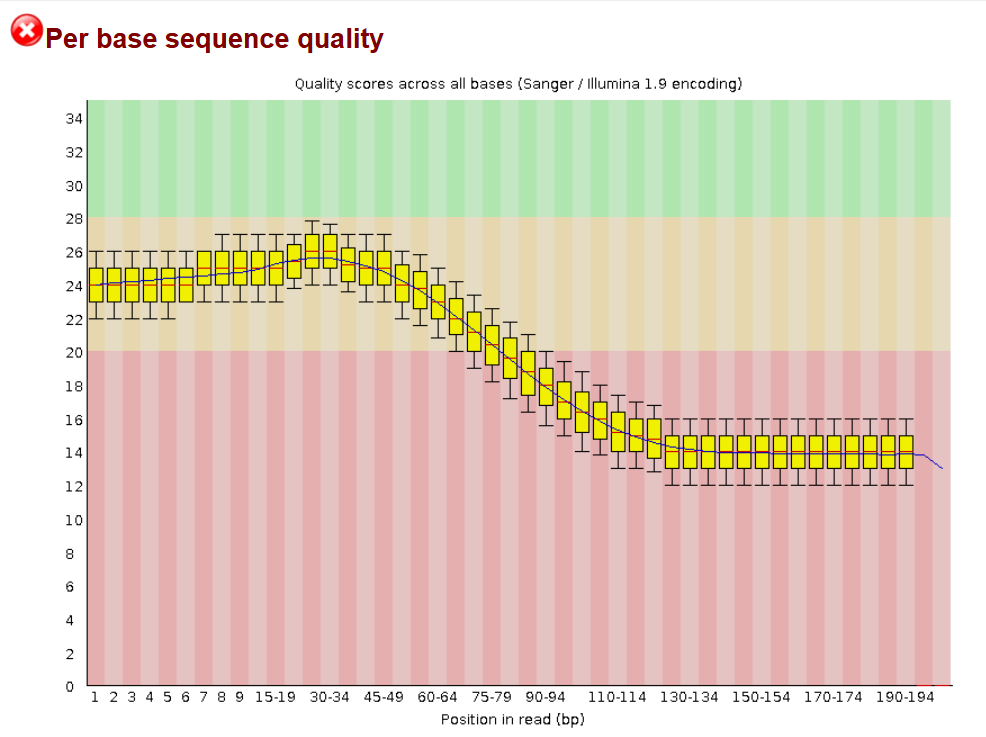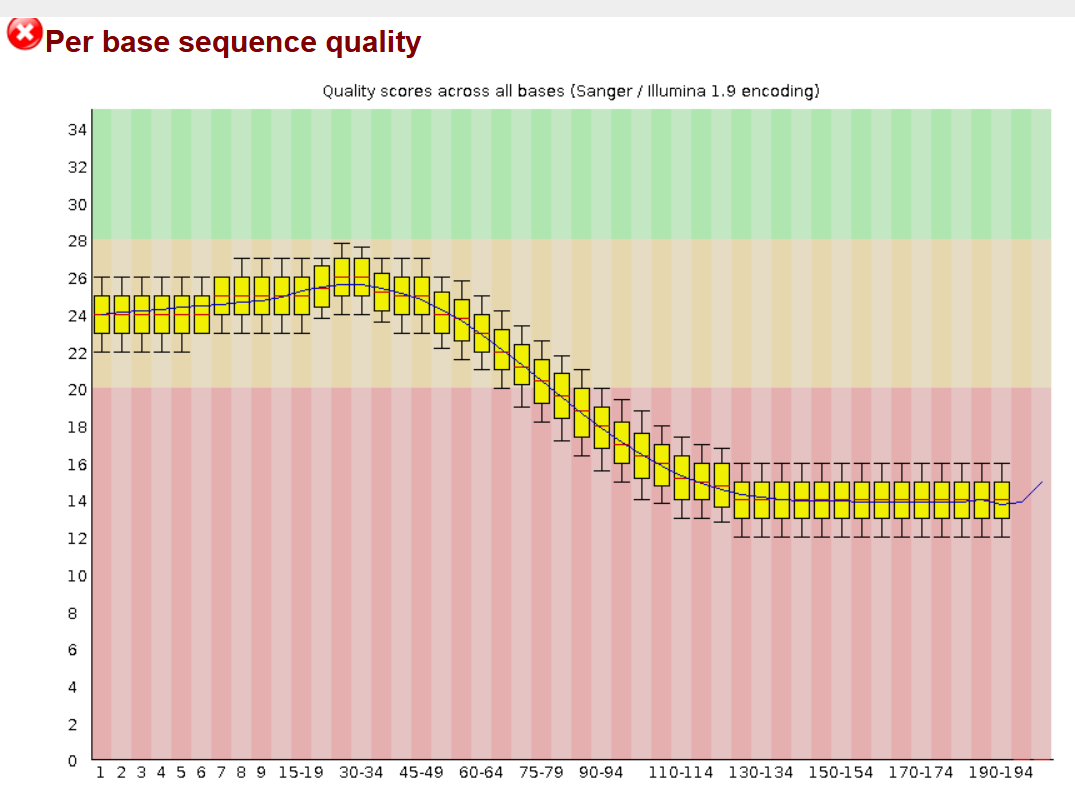

**Arquivo html sumário VEP:**
As variantes estão localizadas no 12, em regiões de íntrons (63%), com baixo número de variantes patogênicas. Há 5 variantes em éxons, sendo 4 missense e uma potencialmente danosa (SIFT e PolyPhen indicam impacto)

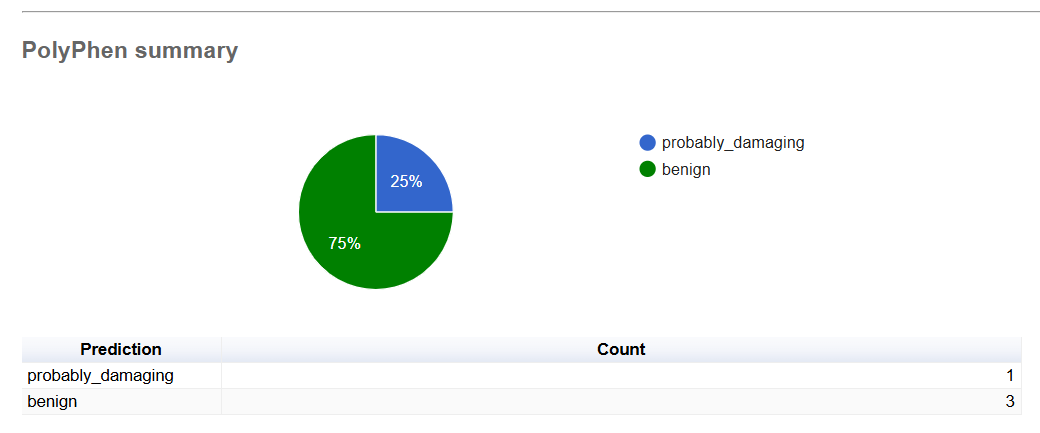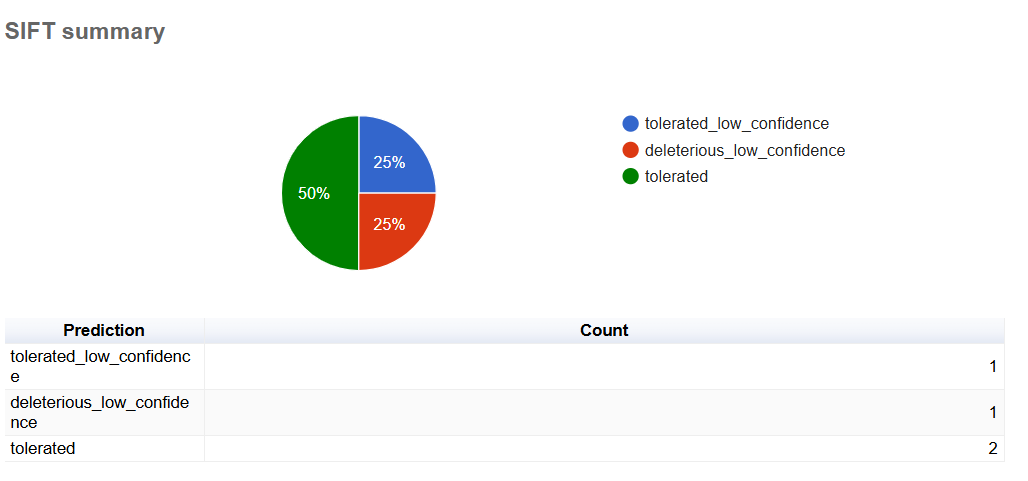

**Arquivo tsv + vcf + visualização IGV:**
Com base nos arquivos gerados, diversas informações foram trazidas sobre essa variante.  Com base na frequência, podemos classificar a variante como heterozigótica no genoma do paciente, além de provavlemente patogénica segundo os critérios da ACMG. A variante encontrada é a PAH, com mutações em T, que deveriam ser C.Ela é uma deleterious_low_confidence(0.02), provavelmente danosa, classificada como patogênica, que ocorre no éxon 7/13.


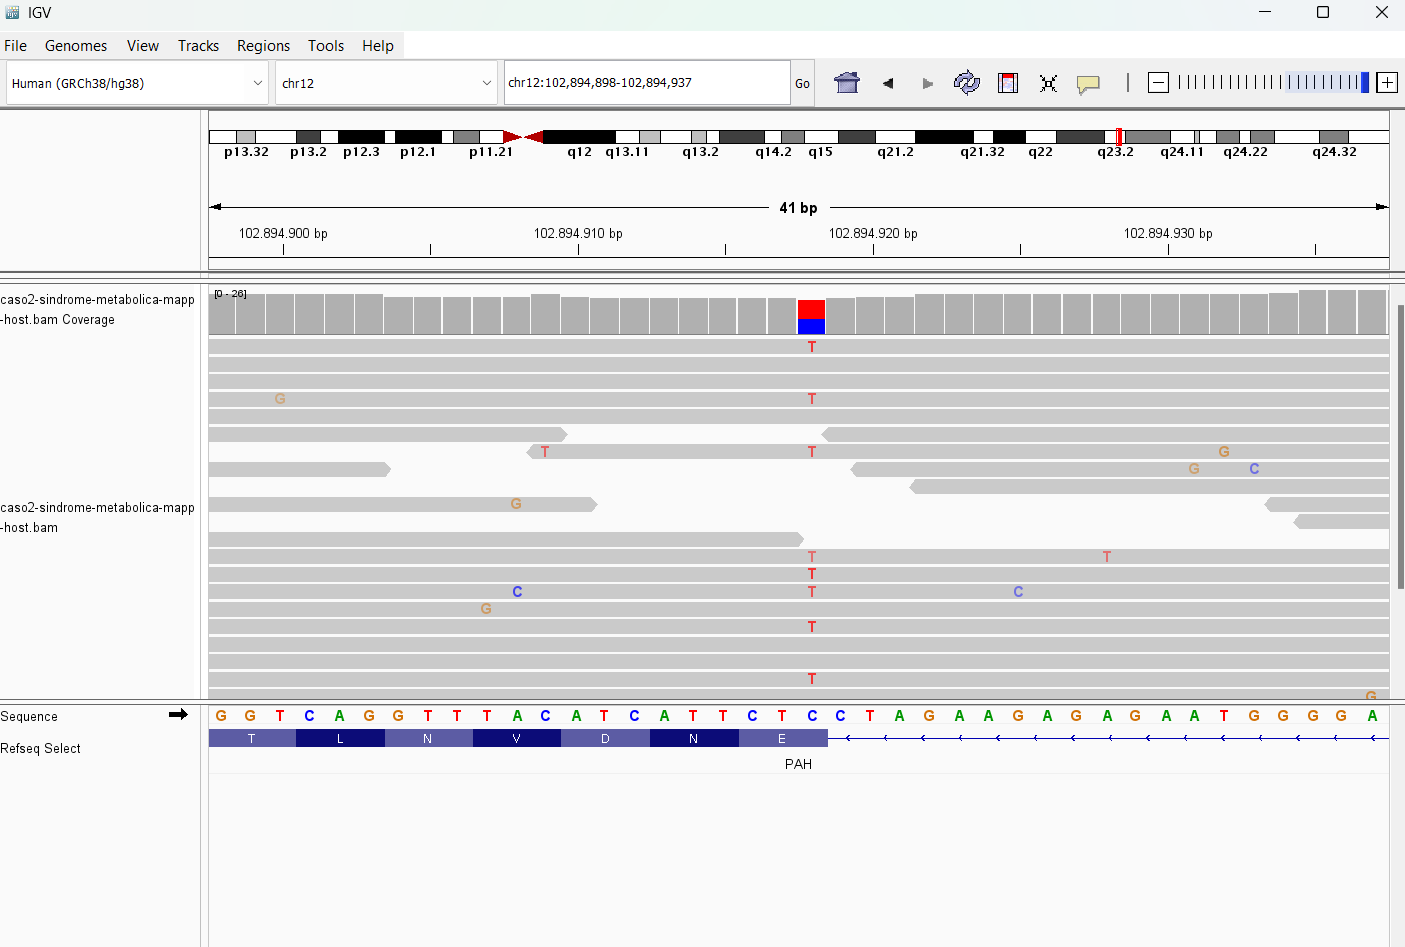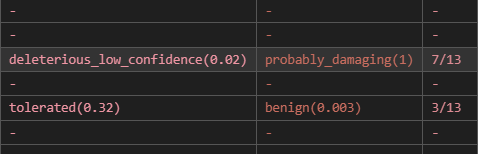

Assim, com base em VAF 0.5 podemos classificar a variante como heterozigótica dominante. As mutações presentes ocorreram muitas vezes em trechos de íntrons, mas a responsável pelo dano foi em um éxon. Há outro gene mutado em um éxon, com classificação benigna, VUS.

  Laudo final


Tipos de variantes:

Intrônicas: 47 (63,5%)

Intergênicas: 14

Missense: 4

Synonymous: 1

Outras não codificantes: 8

Variante de interesse – PAH

Campo	Informação
Gene:	          PAH (Phenylalanine Hydroxylase)
Localização:    (GRCh38)	chr12:102,894,914
Tipo de variante:	Substituição C>T
Conseqüência:	missense_variant
Efeito na proteína:	Troca de aminoácido
SIFT:	deleterious (low confidence)
PolyPhen-2:	probably damaging
ClinVar:	Variante reportada como pathogenic/likely pathogenic (segundo anotações VEP)
VAF (Variant Allele Frequency):	50%
Zigosidade inferida: Heterozigoto

Resultados: A análise identificou uma variante patogênica heterozigota (C>T) no gene PAH, associada à fenilcetonúria (PKU).